# Report from experiments

In [36]:
import json

import pandas as pd
import numpy as np

import torch

from src.data import Full_ECG_DataSet,Hearbeat_ECG_DataSet

from contextlib import suppress
import os

from src.visualize import visualize_latents

## Loading

In [18]:
stats_path = "results"
hb_stats = None
full_stats = None

with suppress(FileNotFoundError):
    with open(os.path.join(stats_path, "results_hb.json")) as f:
        hb_stats =  json.load(f)
with suppress(FileNotFoundError):
    with open(os.path.join(stats_path, "results_full.json")) as f:
        full_stats = json.load(f)

# for f in os.scandir("results")  :
#     if f.is_dir():
#         print(f.name)
        # for f_in in os.scandir(f.path):
        #     print(f_in)

### For heartbeat experiments

In [19]:
df_hb = None
if hb_stats is not None:
    flat_hb_stats = [model for pair in hb_stats for model in pair]

    df_hb = pd.DataFrame(flat_hb_stats)
    df_hb.sort_values(by=["mse"], ascending=True, inplace=True)

### For full ECG signal experiments

In [20]:
df_full = None
if full_stats is not None:
    flat_df = [model for pair in full_stats for model in pair]

    df_full = pd.DataFrame(flat_df)
    df_full.sort_values(by=["mse"], ascending=True, inplace=True)
#df_full

## Basic stats

### Heartbeat stat analysis

#### Clustering

In [21]:
df_hb.sort_values(by=["silhouette"], ascending=False, inplace=True)
df_hb[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
7,LSTM-VAE-HB-big-boy-deeper_Best,0.010571,7.950028,-0.040709,1.863940,0.5990,2.1445,128
6,LSTM-VAE-HB-big-boy-deeper,0.010460,7.995688,-0.037428,1.826388,0.5560,2.0923,128
10,LSTM-VAE-HB-big-wide-latent,0.005578,10.726204,0.012717,1.894216,0.4811,2.5328,192
11,LSTM-VAE-HB-big-wide-latent_Best,0.005460,10.819107,0.002169,1.934434,0.4489,2.5437,192
13,LSTM-VAE-HB-ultra-deeper-wider-latent_Best,0.011529,7.573283,-0.051044,1.467555,0.4115,2.1562,192
49,LSTM-VAE-big-model,0.004035,12.132957,-0.004700,1.559400,0.3462,2.4182,128
38,LSTM-VAE-big-model,0.004035,12.132957,-0.004700,1.559400,0.3462,2.4182,128
37,LSTM-VAE-big-model_Best,0.004200,11.958687,-0.003200,1.628700,0.3443,2.2596,128
48,LSTM-VAE-big-model_Best,0.004200,11.958687,-0.003200,1.628700,0.3443,2.2596,128
28,TRANSFORMER-big-boy,0.000084,28.950150,-0.228985,0.346225,0.1022,1.7496,128


#### Reconstruction

In [22]:
df_hb.sort_values(by=["mse"], ascending=True, inplace=True)
df_hb[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
31,TRANSFORMER-no-reg_Best,0.000031,33.221412,0.130209,0.080511,0.0284,2.4867,3
30,TRANSFORMER-no-reg,0.000032,33.194845,0.130110,0.075097,0.0361,2.4007,1
24,TRANSFORMER-baseline,0.000055,30.808263,-0.186962,0.054138,0.0406,2.2773,0
25,TRANSFORMER-baseline_Best,0.000055,30.772204,-0.184310,0.055746,0.0412,2.3036,0
29,TRANSFORMER-big-boy_Best,0.000079,29.195607,-0.208060,0.302179,0.0797,1.8807,128
28,TRANSFORMER-big-boy,0.000084,28.950150,-0.228985,0.346225,0.1022,1.7496,128
27,TRANSFORMER-stable-baseline_Best,0.000424,21.917064,0.033725,0.143444,0.0536,2.0449,61
26,TRANSFORMER-stable-baseline,0.000599,20.418868,-0.167041,0.116015,0.0397,2.0506,53
35,LSTM-VAE-baseline-pp_Best,0.001793,15.654844,0.735600,7.267800,0.0451,2.8963,96
46,LSTM-VAE-baseline-pp_Best,0.001793,15.654844,0.735600,7.267800,0.0451,2.8963,96


In [23]:
df_hb.sort_values(by=["snr"], ascending=False, inplace=True)
df_hb[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
31,TRANSFORMER-no-reg_Best,0.000031,33.221412,0.130209,0.080511,0.0284,2.4867,3
30,TRANSFORMER-no-reg,0.000032,33.194845,0.130110,0.075097,0.0361,2.4007,1
24,TRANSFORMER-baseline,0.000055,30.808263,-0.186962,0.054138,0.0406,2.2773,0
25,TRANSFORMER-baseline_Best,0.000055,30.772204,-0.184310,0.055746,0.0412,2.3036,0
29,TRANSFORMER-big-boy_Best,0.000079,29.195607,-0.208060,0.302179,0.0797,1.8807,128
28,TRANSFORMER-big-boy,0.000084,28.950150,-0.228985,0.346225,0.1022,1.7496,128
27,TRANSFORMER-stable-baseline_Best,0.000424,21.917064,0.033725,0.143444,0.0536,2.0449,61
26,TRANSFORMER-stable-baseline,0.000599,20.418868,-0.167041,0.116015,0.0397,2.0506,53
35,LSTM-VAE-baseline-pp_Best,0.001793,15.654844,0.735600,7.267800,0.0451,2.8963,96
46,LSTM-VAE-baseline-pp_Best,0.001793,15.654844,0.735600,7.267800,0.0451,2.8963,96


#### Latent quality

In [24]:
import numpy as np
import pandas as pd


def rank_latent_distribution_only(df):
    if df is None or df.empty:
        return None

    df_rank = df.copy()

    # 1. Bezwzględne odchylenie średniej od zera |mean - 0|
    # Im mniejsze, tym lepiej (idealnie = 0)
    mean_dev = np.abs(df_rank["latent_mean"])

    # Normalizujemy karę: 1 oznacza idealne 0, a 0 oznacza najgorszy (najdalszy) odchył w tabeli
    md_min, md_max = mean_dev.min(), mean_dev.max()
    mean_score = (
        1 - (mean_dev - md_min) / (md_max - md_min)
        if md_max != md_min
        else 1.0
    )

    # 2. Bezwzględne odchylenie std od jedynki |std - 1.0|
    # Im mniejsze, tym lepiej (idealnie = 1)
    std_dev = np.abs(df_rank["latent_std"] - 1.0)

    # Normalizujemy karę: 1 oznacza idealne std=1, a 0 oznacza najgorszy odchył (np. std=22)
    std_min, std_max = std_dev.min(), std_dev.max()
    std_score = (
        1 - (std_dev - std_min) / (std_max - std_min)
        if std_max != std_min
        else 1.0
    )

    # 3. Łączny score (wagi pół na pół - idealna średnia i idealne odchylenie)
    df_rank["distribution_quality_score"] = 0.5 * mean_score + 0.5 * std_score

    df_rank.sort_values(
        by="distribution_quality_score", ascending=False, inplace=True
    )

    return df_rank[
        [
            "name",
            "distribution_quality_score",
            "latent_mean",
            "latent_std",
            "active_dims",
        ]
    ]


# Uruchomienie rankingu rozkładu
df_hb_dist_ranking = rank_latent_distribution_only(df_hb)
df_hb_dist_ranking.head(10)

,name,distribution_quality_score,latent_mean,latent_std,active_dims
9,LSTM-VAE-HB-big-high-reg_Best,0.996990,-0.007319,1.052316,128
15,LSTM-VAE-HB-deeper-high-reg_Best,0.995776,-0.000980,0.785158,192
0,CNN-HB-deeper,0.994727,-0.003580,1.215835,64
1,CNN-HB-deeper_Best,0.994727,-0.003580,1.215835,64
14,LSTM-VAE-HB-deeper-high-reg,0.992472,-0.005030,0.710644,192
16,CNN-baseline,0.990735,-0.000248,0.552167,64
17,CNN-baseline_Best,0.990007,0.002245,0.554790,64
8,LSTM-VAE-HB-big-high-reg,0.988345,-0.029754,1.042843,128
38,LSTM-VAE-big-model,0.986425,-0.004700,1.559400,128
49,LSTM-VAE-big-model,0.986425,-0.004700,1.559400,128


### Full models analysis

#### Reconstructing

In [58]:
df_full.sort_values(by=["mse"], ascending=True, inplace=True)
df_full[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
7,FULL-LSTM-big_Best,0.022250,3.899998,0.026762,3.870337,0.4292,2.4408,192
5,FULL-LSTM-deep_Best,0.022754,3.802688,-0.002993,3.155480,0.5191,2.2034,128
6,FULL-LSTM-big,0.023260,3.707238,0.048509,7.807772,0.2629,2.4464,192
4,FULL-LSTM-deep,0.023399,3.681315,0.014365,5.293466,0.4293,2.2032,128
9,FULL-LSTM-big-ratio_Best,0.025540,3.301106,-0.020128,4.272303,0.4387,2.1774,192
8,FULL-LSTM-big-ratio,0.030733,2.497321,-0.248857,7.302122,0.2653,2.4672,192
3,FULL-CNN-deeper_Best,0.048637,0.503720,0.092089,58.130981,0.1823,1.3591,128
2,FULL-CNN-deeper,0.049756,0.404898,0.717147,94.509521,0.1572,1.4998,128
1,FULL-CNN-deep_Best,0.050437,0.345834,-3.130232,27.013865,0.1447,1.5432,128
0,FULL-CNN-deep,0.051770,0.232603,-3.024617,28.029436,0.1188,1.6607,128


In [26]:
df_full.sort_values(by=["snr"], ascending=False, inplace=True)
df_full[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
7,FULL-LSTM-big_Best,0.022250,3.899998,0.026762,3.870337,0.4292,2.4408,192
5,FULL-LSTM-deep_Best,0.022754,3.802688,-0.002993,3.155480,0.5191,2.2034,128
6,FULL-LSTM-big,0.023260,3.707238,0.048509,7.807772,0.2629,2.4464,192
4,FULL-LSTM-deep,0.023399,3.681315,0.014365,5.293466,0.4293,2.2032,128
9,FULL-LSTM-big-ratio_Best,0.025540,3.301106,-0.020128,4.272303,0.4387,2.1774,192
8,FULL-LSTM-big-ratio,0.030733,2.497321,-0.248857,7.302122,0.2653,2.4672,192
3,FULL-CNN-deeper_Best,0.048637,0.503720,0.092089,58.130981,0.1823,1.3591,128
2,FULL-CNN-deeper,0.049756,0.404898,0.717147,94.509521,0.1572,1.4998,128
1,FULL-CNN-deep_Best,0.050437,0.345834,-3.130232,27.013865,0.1447,1.5432,128
0,FULL-CNN-deep,0.051770,0.232603,-3.024617,28.029436,0.1188,1.6607,128


#### Clustering

In [59]:
df_full.sort_values(by=["silhouette"], ascending=False, inplace=True)
df_full[['name', 'mse', 'snr', 'latent_mean', 'latent_std', 'silhouette', 'davies_bouldin','active_dims']].head(10)

,name,mse,snr,latent_mean,latent_std,silhouette,davies_bouldin,active_dims
5,FULL-LSTM-deep_Best,0.022754,3.802688,-0.002993,3.155480,0.5191,2.2034,128
9,FULL-LSTM-big-ratio_Best,0.025540,3.301106,-0.020128,4.272303,0.4387,2.1774,192
4,FULL-LSTM-deep,0.023399,3.681315,0.014365,5.293466,0.4293,2.2032,128
7,FULL-LSTM-big_Best,0.022250,3.899998,0.026762,3.870337,0.4292,2.4408,192
8,FULL-LSTM-big-ratio,0.030733,2.497321,-0.248857,7.302122,0.2653,2.4672,192
6,FULL-LSTM-big,0.023260,3.707238,0.048509,7.807772,0.2629,2.4464,192
3,FULL-CNN-deeper_Best,0.048637,0.503720,0.092089,58.130981,0.1823,1.3591,128
2,FULL-CNN-deeper,0.049756,0.404898,0.717147,94.509521,0.1572,1.4998,128
1,FULL-CNN-deep_Best,0.050437,0.345834,-3.130232,27.013865,0.1447,1.5432,128
0,FULL-CNN-deep,0.051770,0.232603,-3.024617,28.029436,0.1188,1.6607,128


#### Latent quality

In [28]:
df_full_dist_ranking = rank_latent_distribution_only(df_full)
df_full_dist_ranking.head(10)

,name,distribution_quality_score,latent_mean,latent_std,active_dims
18,FULL-TRANSFORMER-big-deep,0.997296,-0.015978,0.809466,256
23,FULL-TRANSFORMER-wide_Best,0.996103,0.000471,0.124243,125
19,FULL-TRANSFORMER-big-deep_Best,0.995951,-0.025815,0.851896,256
22,FULL-TRANSFORMER-wide,0.991505,0.029115,0.120041,111
5,FULL-LSTM-deep_Best,0.988847,-0.002993,3.155480,128
14,FULL-TRANSFORMER-latent-256,0.981884,-0.092772,0.222612,256
7,FULL-LSTM-big_Best,0.981221,0.026762,3.870337,192
9,FULL-LSTM-big-ratio_Best,0.980128,-0.020128,4.272303,192
15,FULL-TRANSFORMER-latent-256_Best,0.978040,-0.117917,0.254791,256
4,FULL-LSTM-deep,0.975580,0.014365,5.293466,128


## Latent playground

In [29]:
from torch.utils.data import DataLoader
import kagglehub

print("Downloading dataset...", end=" ")
path = kagglehub.dataset_download("khyeh0719/ptb-xl-dataset")
print(f"Done! Path is = {os.path.normpath(os.path.join(path, 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'))}")

ds_path = os.path.normpath(os.path.join(path, "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"))
test_ds_path = os.path.normpath("./dataset/ptb_xl_test/")

print("Loading dataset...\n", end=' ')
test_ds = Hearbeat_ECG_DataSet(path=ds_path, mode="test")
test_ds_full = Full_ECG_DataSet(path=ds_path, mode="test")
test_loader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)
test_loader_full = DataLoader(test_ds_full, batch_size=len(test_ds_full), shuffle=False)
print("Done")

Loading dataset...
 

Processing SCP codes: 100%|██████████| 2203/2203 [00:00<00:00, 40735.94it/s]

Done


In [31]:
_, true_labels = next(iter(test_loader))

In [34]:
_, true_labels_full = next(iter(test_loader_full))

### Help funcs

In [56]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import f1_score, hamming_loss
import torch


def evaluate_latent_clustering_suite(X_tensor, Y_tensor, visualize_fn=None):
    # 1. Konwersja do NumPy dla sklearn
    X_np = (
        X_tensor.cpu().detach().numpy()
        if hasattr(X_tensor, "cpu")
        else np.array(X_tensor)
    )
    Y_np = (
        Y_tensor.cpu().detach().numpy()
        if hasattr(Y_tensor, "cpu")
        else np.array(Y_tensor)
    )

    unique_combinations = np.unique(Y_np, axis=0)
    n_clusters_base = len(unique_combinations)

    print(f"=== ROZPOCZĘCIE ANALIZY KLASTERYZACJI ===")
    print(f"Kształt danych Latent: {X_np.shape}")
    print(f"Liczba unikalnych kombinacji klas w Y: {n_clusters_base}\n")

    algorithms = {
        "K-Means": KMeans(
            n_clusters=n_clusters_base, random_state=42, n_init="auto"
        ),
        "Agglomerative (Hierarchical)": AgglomerativeClustering(
            n_clusters=n_clusters_base
        ),
    }

    summary_results = {}

    for name, algo in algorithms.items():
        print(f"--- Uruchamianie algorytmu: {name} ---")

        # Predykcja klastrów (wektor 1D)
        cluster_labels_np = algo.fit_predict(X_np)

        # Mapowanie profili binarnych do wyliczenia błędu
        Y_pred = np.zeros_like(Y_np)
        for cluster_id in np.unique(cluster_labels_np):
            indices = np.where(cluster_labels_np == cluster_id)[0]
            if len(indices) > 0:
                mean_profile = Y_np[indices].mean(axis=0)
                Y_pred[indices] = (mean_profile >= 0.5).astype(int)

        # Metryki błędu
        h_loss = hamming_loss(Y_np, Y_pred)
        f1_macro = f1_score(Y_np, Y_pred, average="macro", zero_division=0)

        print(f" -> Hamming Loss: {h_loss:.4f}")
        print(f" -> F1-Score (Macro): {f1_macro:.4f}")

        summary_results[name] = {"hamming_loss": h_loss, "f1_macro": f1_macro}

        # 2. PRZYGOTOWANIE STRUKTURY POD WIZUALIZACJĘ
        if visualize_fn is not None:
            print(f" -> Generowanie wizualizacji dla {name}...")

            # Konwertujemy wektor klastrów 1D na macierz 2D One-Hot (udajemy format multi-label)
            # Dzięki temu np. wartość 3 stanie się [0, 0, 0, 1, 0, 0...]
            num_discovered_clusters = len(np.unique(cluster_labels_np))
            one_hot_clusters = np.zeros(
                (len(cluster_labels_np), num_discovered_clusters)
            )
            one_hot_clusters[
                np.arange(len(cluster_labels_np)), cluster_labels_np
            ] = 1

            # Pakujemy w Tensory, które bez problemu przytulą .detach().cpu().numpy()
            visualize_targets = torch.from_numpy(one_hot_clusters).float()
            visualize_latents_tensor = X_tensor.clone().detach()

            # Odpalamy rysowanie
            visualize_fn(
                latents=visualize_latents_tensor, targets=visualize_targets
            )

        print("-" * 50 + "\n")

    return summary_results

In [55]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, hamming_loss
from sklearn.model_selection import train_test_split
# Prawidłowy import dla standardowego scikit-learn
from sklearn.multioutput import ClassifierChain, MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import torch


def benchmark_latent_classification(
    X_tensor, Y_tensor, test_size=0.2, random_state=42
):
    """Odpala stabilny benchmark klasyfikacji multi-label na przestrzeni

    ukrytej.
    """
    # 1. Konwersja na NumPy
    X_np = (
        X_tensor.cpu().detach().numpy()
        if hasattr(X_tensor, "cpu")
        else np.array(X_tensor)
    )
    Y_np = (
        Y_tensor.cpu().detach().numpy()
        if hasattr(Y_tensor, "cpu")
        else np.array(Y_tensor)
    )

    print("=== ROZPOCZĘCIE BENCHMARKU KLASYFIKACJI ===")
    print(f"Rozmiar danych: X={X_np.shape}, Y={Y_np.shape}\n")

    # 2. Podział na zbiór treningowy i testowy
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_np, Y_np, test_size=test_size, random_state=random_state
    )

    # 3. Definicja modeli przy użyciu MultiOutput oraz ClassifierChain
    models = {
        "SVM (RBF) + MultiOutput": MultiOutputClassifier(
            SVC(kernel="rbf", C=1.0, random_state=random_state)
        ),
        "SVM (RBF) + Classifier Chain": ClassifierChain(
            SVC(kernel="rbf", C=1.0, random_state=random_state)
        ),
        "Random Forest (Natywny Multi-label)": RandomForestClassifier(
            n_estimators=100, random_state=random_state, n_jobs=-1
        ),
        "KNN + MultiOutput": MultiOutputClassifier(
            KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        ),
    }

    results_records = []

    # 4. Pętla treningowa i ewaluacyjna
    for name, model in models.items():
        print(f"Trenowanie modelu: {name}...")
        model.fit(X_train, Y_train)

        # Predykcja
        Y_pred = model.predict(X_test)

        # Na wypadek gdyby ClassifierChain rzucił macierz rzadką (sparse)
        if hasattr(Y_pred, "toarray"):
            Y_pred = Y_pred.toarray()

        Y_pred = (Y_pred >= 0.5).astype(int)

        # Metryki
        h_loss = hamming_loss(Y_test, Y_pred)
        f1_macro = f1_score(Y_test, Y_pred, average="macro", zero_division=0)
        f1_micro = f1_score(Y_test, Y_pred, average="micro", zero_division=0)

        print(f" -> Hamming Loss: {h_loss:.4f} | F1 Macro: {f1_macro:.4f}")

        results_records.append(
            {
                "Model": name,
                "Hamming Loss": h_loss,
                "F1 Macro": f1_macro,
                "F1 Micro": f1_micro,
            }
        )

    # 5. Tabela końcowa
    df_results = pd.DataFrame(results_records)
    df_results.sort_values(by="F1 Macro", ascending=False, inplace=True)

    print("\n" + "=" * 60)
    print(" OSTATECZNY RAPORT BENCHMARKU KLASYFIKACJI")
    print("=" * 60)
    display(df_results)
    print("=" * 60)

    return df_results

### Heartbeat models

We can clearly see that `LSTM-VAE-HB-big-boy-deeper_Best` done best on our clustering task for heartbeart. We gonna test the heartbeat how it looks like

In [45]:
path_to_latent = os.path.join(stats_path, "heartbeat","LSTM-VAE-HB-big-boy-deeper","LSTM-VAE-HB-big-boy-deeper_Best_latents.pt")
tensor = torch.load(path_to_latent)
#visualize_latents(latents=tensor, targets=true_labels)

<class 'torch.Tensor'>


=== ROZPOCZĘCIE ANALIZY KLASTERYZACJI ===
Kształt danych Latent: (25180, 128)
Liczba unikalnych kombinacji klas w Y: 19

--- Uruchamianie algorytmu: K-Means ---
 -> Hamming Loss: 0.2373
 -> F1-Score (Macro): 0.2020
 -> Generowanie wizualizacji dla K-Means...


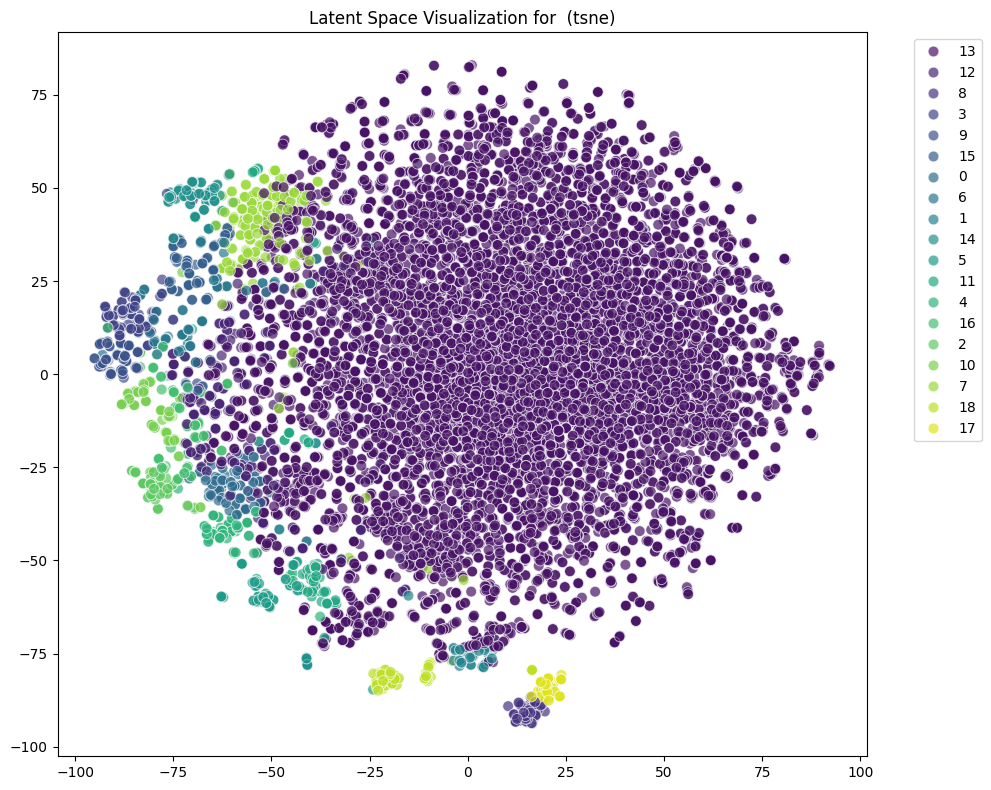

--------------------------------------------------

--- Uruchamianie algorytmu: Agglomerative (Hierarchical) ---
 -> Hamming Loss: 0.2385
 -> F1-Score (Macro): 0.1694
 -> Generowanie wizualizacji dla Agglomerative (Hierarchical)...


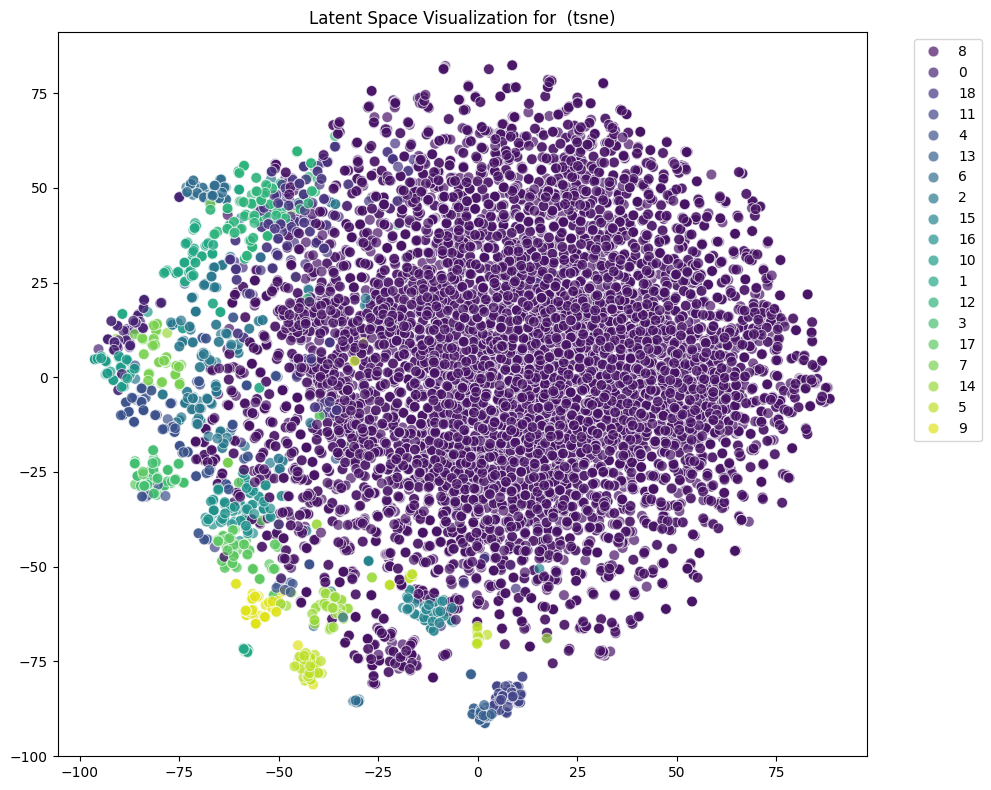

--------------------------------------------------



{'K-Means': {'hamming_loss': 0.23733915806195394,
  'f1_macro': 0.20195695245841616},
 'Agglomerative (Hierarchical)': {'hamming_loss': 0.23854646544876887,
  'f1_macro': 0.16938410018676978}}

In [52]:
evaluate_latent_clustering_suite(X_tensor=tensor, Y_tensor=true_labels,visualize_fn=visualize_latents)

In [57]:
benchmark_latent_classification(tensor, true_labels, test_size=0.2, random_state=42)

=== ROZPOCZĘCIE BENCHMARKU KLASYFIKACJI ===
Rozmiar danych: X=(25180, 128), Y=(25180, 5)

Trenowanie modelu: SVM (RBF) + MultiOutput...
 -> Hamming Loss: 0.1216 | F1 Macro: 0.6850
Trenowanie modelu: SVM (RBF) + Classifier Chain...
 -> Hamming Loss: 0.1210 | F1 Macro: 0.7147
Trenowanie modelu: Random Forest (Natywny Multi-label)...
 -> Hamming Loss: 0.0894 | F1 Macro: 0.7725
Trenowanie modelu: KNN + MultiOutput...
 -> Hamming Loss: 0.0440 | F1 Macro: 0.9060

 OSTATECZNY RAPORT BENCHMARKU KLASYFIKACJI


,Model,Hamming Loss,F1 Macro,F1 Micro
3,KNN + MultiOutput,0.044003,0.906013,0.911755
2,Random Forest (Natywny Multi-label),0.089396,0.772454,0.799430
1,SVM (RBF) + Classifier Chain,0.121048,0.714666,0.747138
0,SVM (RBF) + MultiOutput,0.121644,0.685009,0.725464


,Model,Hamming Loss,F1 Macro,F1 Micro
3,KNN + MultiOutput,0.044003,0.906013,0.911755
2,Random Forest (Natywny Multi-label),0.089396,0.772454,0.799430
1,SVM (RBF) + Classifier Chain,0.121048,0.714666,0.747138
0,SVM (RBF) + MultiOutput,0.121644,0.685009,0.725464


### Full ECG models

In [60]:
path_to_latent = os.path.join(stats_path, "full_ecg","FULL-LSTM-deep","FULL-LSTM-deep_Best_latents.pt")
tensor_full = torch.load(path_to_latent)

=== ROZPOCZĘCIE ANALIZY KLASTERYZACJI ===
Kształt danych Latent: (2203, 128)
Liczba unikalnych kombinacji klas w Y: 19

--- Uruchamianie algorytmu: K-Means ---
 -> Hamming Loss: 0.2509
 -> F1-Score (Macro): 0.0503
 -> Generowanie wizualizacji dla K-Means...


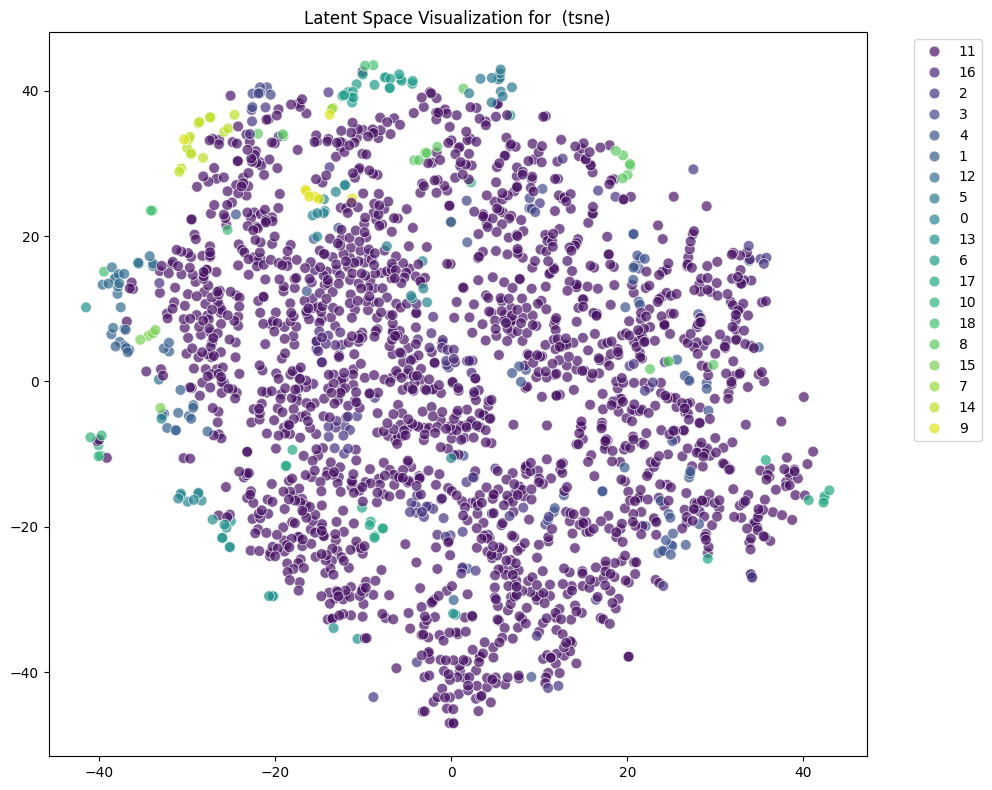

--------------------------------------------------

--- Uruchamianie algorytmu: Agglomerative (Hierarchical) ---
 -> Hamming Loss: 0.2497
 -> F1-Score (Macro): 0.0626
 -> Generowanie wizualizacji dla Agglomerative (Hierarchical)...


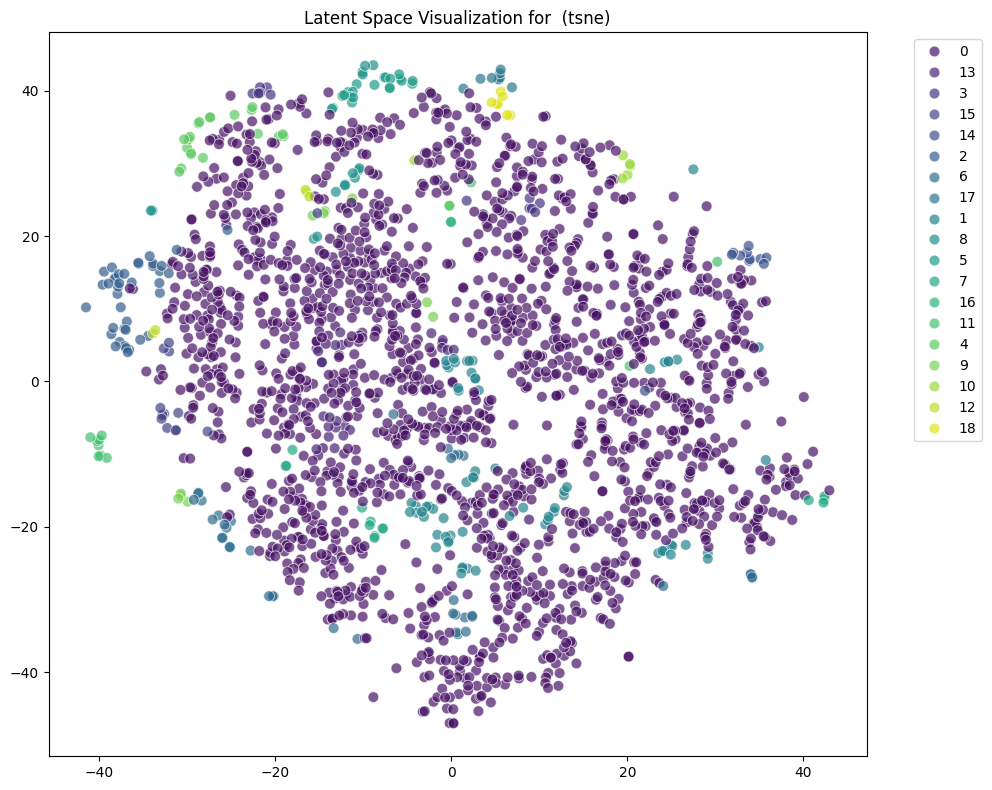

--------------------------------------------------



{'K-Means': {'hamming_loss': 0.2509305492510213,
  'f1_macro': 0.05028101731633701},
 'Agglomerative (Hierarchical)': {'hamming_loss': 0.24965955515206537,
  'f1_macro': 0.06255735805141907}}

In [61]:
evaluate_latent_clustering_suite(X_tensor=tensor_full, Y_tensor=true_labels_full,visualize_fn=visualize_latents)

In [62]:
benchmark_latent_classification(tensor_full, true_labels_full, test_size=0.2, random_state=42)


=== ROZPOCZĘCIE BENCHMARKU KLASYFIKACJI ===
Rozmiar danych: X=(2203, 128), Y=(2203, 5)

Trenowanie modelu: SVM (RBF) + MultiOutput...
 -> Hamming Loss: 0.2272 | F1 Macro: 0.1302
Trenowanie modelu: SVM (RBF) + Classifier Chain...
 -> Hamming Loss: 0.2227 | F1 Macro: 0.1415
Trenowanie modelu: Random Forest (Natywny Multi-label)...
 -> Hamming Loss: 0.2408 | F1 Macro: 0.1151
Trenowanie modelu: KNN + MultiOutput...
 -> Hamming Loss: 0.2594 | F1 Macro: 0.2431

 OSTATECZNY RAPORT BENCHMARKU KLASYFIKACJI


,Model,Hamming Loss,F1 Macro,F1 Micro
3,KNN + MultiOutput,0.259410,0.243062,0.361607
1,SVM (RBF) + Classifier Chain,0.222676,0.141548,0.313287
0,SVM (RBF) + MultiOutput,0.227211,0.130240,0.277056
2,Random Forest (Natywny Multi-label),0.240816,0.115075,0.220264


,Model,Hamming Loss,F1 Macro,F1 Micro
3,KNN + MultiOutput,0.259410,0.243062,0.361607
1,SVM (RBF) + Classifier Chain,0.222676,0.141548,0.313287
0,SVM (RBF) + MultiOutput,0.227211,0.130240,0.277056
2,Random Forest (Natywny Multi-label),0.240816,0.115075,0.220264
